### Задачи:

1) У 23 человек совпадут дни рождения (50%)

In [51]:
from random import shuffle

l = [1,2,3,4,5]
print(l)
shuffle(l)
print(l)

[1, 2, 3, 4, 5]
[3, 2, 5, 1, 4]


In [52]:
l2 = []
for i in range(5):
  shuffle(l)
  l2.append(l[0])
l2

[4, 5, 4, 3, 5]

In [53]:
len(set(l2))

3

In [54]:
if len(l2) != len(set(l2)):
  print('Found a duplicate')

Found a duplicate


In [55]:
import numpy as np
from tqdm import tqdm
is_dup = []
n = 10_000
l = list(range(365))# дней в году

for i in tqdm(range(n)):

  l2 = []
  for i in range(23):
    shuffle(l)
    l2.append(l[0])

  if len(l2) != len(set(l2)):
    is_dup.append(1)
  else:
    is_dup.append(0)

sum(is_dup)/len(is_dup)

100%|██████████| 10000/10000 [00:23<00:00, 429.93it/s]


0.5007

2) Выучил 20 из 30 билетов. Каким по счёту лучше идти сдавать экзамен?

In [56]:
from collections import defaultdict
d = defaultdict(list)
n = 100000
res = []

for i in range(0, 30):
  succ=0
  for iter in range(n):
    l = list(range(1, 31))
    shuffle(l)
    if l[i] <= 20: succ+=1
  prob = succ/n
  res.append(succ)

max(res), np.argmax(res)

(66946, 6)

<BarContainer object of 30 artists>

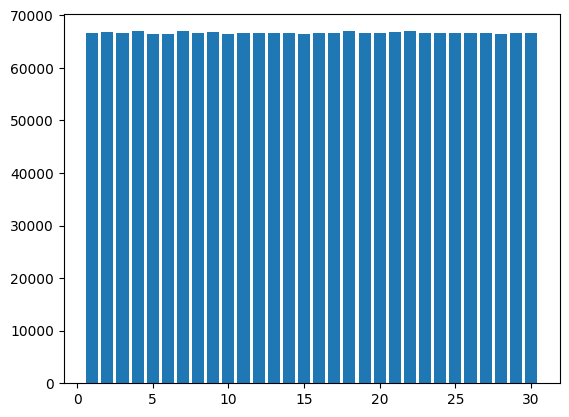

In [57]:
import matplotlib.pyplot as plt
plt.bar(list(range(1, 31)), res)

3) Ночью таксист совершил наезд и скрылся с места происшествия. В городе работают две компании такси, «Зеленая» и «Синяя». Вам представили следующие данные:
85% городских такси — из «Зеленой» компании, а 15% — из «Синей».
Свидетель опознал такси как «Синее». Судебная экспертиза проверила надежность свидетеля в ночных условиях и заключила, что свидетель правильно опознает каждый из двух цветов в 80% случаев и неправильно — в 20% случаев.
Какова вероятность того, что такси, совершившее наезд, было «Синим», а не «Зеленым»?
Правильный ответ на задачу с таксистом — 41%. Считать нужно так.

1. Всего есть четыре варианта ДТП. Свидетель верно опознал синих, свидетель неверно опознал синих, свидетель верно опознал зелёных, свидетель неверно опознал зелёных.

2. Свидетель назвал синий цвет, поэтому нас интересуют два варианта — свидетель верно опознал синих и свидетель неверно опознал зелёных.

3. Вероятность наезда синего такси — 15%. Вероятность правильного опознания — 80%. Вероятность правильного опознания синих — 15% * 80% = 12%.

4. Вероятность наезда зелёного такси — 85%. Вероятность неверного опознания — 20%. Вероятность неверного опознания зелёных — 85% * 20% = 17%.

5. Получается, что из тех 29% (12% + 17%) случаев, когда свидетель назвал синий цвет, вероятность того, что это и вправду был синий — 12% / 29% = 41%.

In [58]:
scale = 100
l = np.array([0]*85*scale+[1]*15*scale)
l2 = np.array([1]*80*scale+[0]*20*scale)
shuffle(l), shuffle(l2)
#l, l2

(None, None)

In [59]:
# code #3
l3 = np.logical_not(np.logical_xor(l, l2))
l3

array([False,  True, False, ...,  True, False, False])

In [60]:
sum(l3)/len(l3)

0.2914

In [61]:
import numpy as np
import pandas as pd

4) Мороженное любят 80%. Из 100 опрошенных мороженное любят 75. Какая вероятность, что при опросе мы получим 75 и меньше?

In [62]:
np.random.binomial(1, 0.5)

1

In [63]:
sum([np.random.binomial(1, 0.5) for i in range(100)])

48

In [64]:
np.random.binomial(1, 0.8, size=100)

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [65]:
np.random.binomial(1, 0.8, size=100).mean()

0.85

In [66]:
np.random.binomial(1, 0.8, size=100).mean() <= 0.75

False

In [67]:
[np.random.binomial(1, 0.8, size=100).mean() <= 0.75 for i in range(10)]

[False, False, False, False, True, False, False, False, False, False]

In [68]:
np.mean([np.random.binomial(1, 0.8, size=100).mean() <= 0.75 for i in range(10000)])

0.1324

P-value: 0.1277

0.1277 > 0.05

Значит мы не можем отвергнуть гипотезу про 80%

In [69]:
from statsmodels.stats.proportion import proportions_ztest as ztest
ztest(75, 100, value=0.8, alternative='smaller')

(-1.1547005383792526, 0.12410653949496159)

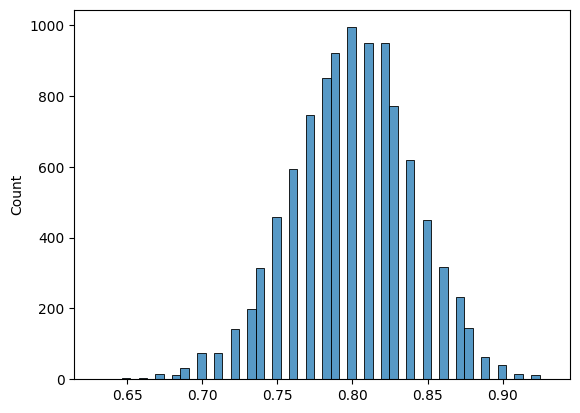

In [70]:
import seaborn as sns
sns.histplot([np.random.binomial(1, 0.8, size=100).mean() for i in range(10000)]);

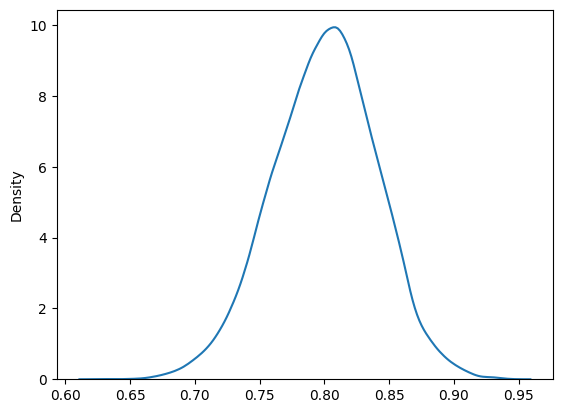

In [71]:
sns.kdeplot([np.random.binomial(1, 0.8, size=100).mean() for i in range(10000)]);

5) Есть Landing Page A и B. Новый дизайн показали 30% пользователей из 1000.

In [72]:
import pandas as pd
df = pd.DataFrame({'page': ['A','B'], 'lead': [700, 300], 'sale':[70, 48]})
df['cr'] = df['sale'] / df['lead'] # Conversion Rate
df

,page,lead,sale,cr
0,A,700,70,0.10
1,B,300,48,0.16


Какова вероятность, что результат случайный?

In [73]:
(70 + 48) / 1000

0.118

In [74]:
np.random.binomial(1, 0.118, size=700).mean()

0.11142857142857143

In [75]:
np.random.binomial(1, 0.118, size=300).mean()

0.12

In [76]:
np.random.binomial(1, 0.118, size=700).mean() - np.random.binomial(1, 0.118, size=300).mean()

0.023809523809523822

In [77]:
abs(np.random.binomial(1, 0.118, size=700).mean() - np.random.binomial(1, 0.118, size=300).mean())

0.01428571428571429

In [78]:
abs(0.1 - 0.16)

0.06

In [79]:
abs(np.random.binomial(1, 0.118, size=700).mean() - np.random.binomial(1, 0.118, size=300).mean()) >= 0.06

False

In [80]:
[abs(np.random.binomial(1, 0.118, size=700).mean() - np.random.binomial(1, 0.118, size=300).mean()) >= 0.06 for i in range(10)]

[False, False, False, False, False, False, False, False, False, False]

In [81]:
np.mean([abs(np.random.binomial(1, 0.118, size=700).mean() - np.random.binomial(1, 0.118, size=300).mean()) >= 0.06 for i in range(10000)])

0.0086

https://www.evanmiller.org/ab-testing/chi-squared.html

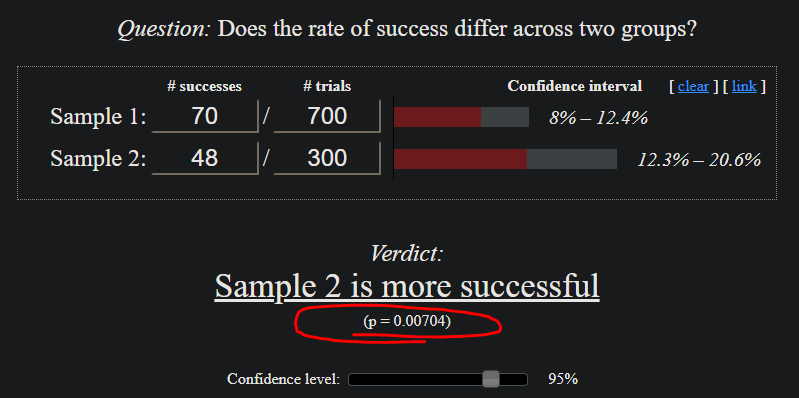

In [82]:
ztest([70, 48], [700, 300])

(-2.695166510284625, 0.007035346384355496)

In [83]:
np.mean([abs(np.random.binomial(1, 0.1, size=700).mean() - np.random.binomial(1, 0.16, size=300).mean()) >= 0.06 for i in range(1000)])

0.507

In [84]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest as ztest
from scipy.stats import norm
from tqdm.notebook import tqdm
import scipy.stats as stats
import matplotlib.pyplot as plt

https://www.evanmiller.org/ab-testing/sample-size.html

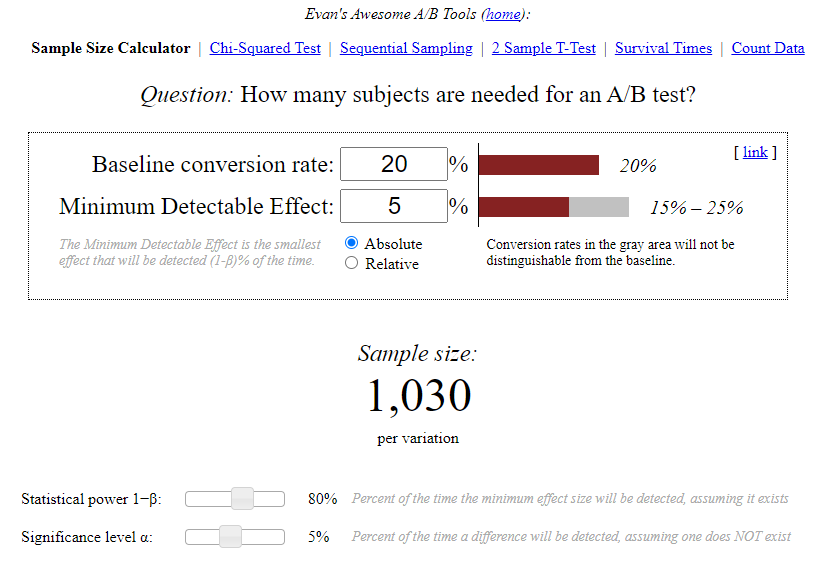

In [85]:
baseline = 0.2
mde = 0.05
sample_size = 1030

Если нет разницы между А и В, то (ошибочно) в 5% случаях мы фиксируем статистически значимый результат.

In [86]:
def ab_test():
  a = np.random.binomial(1, baseline, size=sample_size)
  b = np.random.binomial(1, baseline, size=sample_size)
  _, p_val = ztest([a.sum(), b.sum()], [len(a), len(b)], alternative='two-sided')
  return p_val

np.mean([ab_test() < 0.05 for i in range(10000)])

0.0517

А если разница есть между А и В в 5%, то (ошибочно) в 20% (β) случаях мы НЕ фиксируем статистически значимый результат.

In [87]:
# code #4
def ab_test():
  a = np.random.binomial(1, baseline, size=sample_size)
  b = np.random.binomial(1, baseline+mde, size=sample_size)
  _, p_val = ztest([a.sum(), b.sum()], [len(a), len(b)], alternative='two-sided')
  return p_val

np.mean([ab_test() > 0.05 for i in range(10000)])

0.2228

#«P-HACKING»
Может выражаться в:

* создании одинаковых тестов, до тех пор, пока не будет получен статистически
значимый результат;
* чистке данных от «выбросов», которые таковыми не являются, чтобы снизить уровень p-value до границы и признать тест статистически значимым;
* накоплении данных, чтобы увеличить шансы статистически значимого результата (после прохождения заранее оговоренной точки принятия решения). Проблема не в том, что накапливать больше данных это плохо, а в том, что мы делаем это для тех гипотез, которые нам нравятся;
* остановке теста, как только значение p-value достигло границ стат. значимости (проблема подглядывания). Если вы начинаете проверять результаты с определенной частотой и готовы при наличии различий действовать, то вместо вопроса о том, является ли разница значимой в определенный заранее выбранный момент в будущем, вы спрашиваете, выходит ли разница за диапазон неразличимости хотя бы раз в процессе сбора данных. Это два совершенно разных вопроса. Даже если две группы идентичны, то разница конверсий может периодически выходить за границы зоны неразличимости по мере накопления наблюдений. Это совершенно нормально, так как границы сформированы так, чтобы при тестировании одинаковых версий лишь в 95% случаев разница оказывалась в их пределах. Поэтому, при регулярной проверке результатов в процессе проведения теста с готовностью принять решение при наличии значимой разницы вы начинаете кумулятивно накапливать возможные случайные моменты, когда разница выходит за пределы диапазона. Даже если тест достиг значимости, не прекращайте его. Ждите нужного объема выборки.

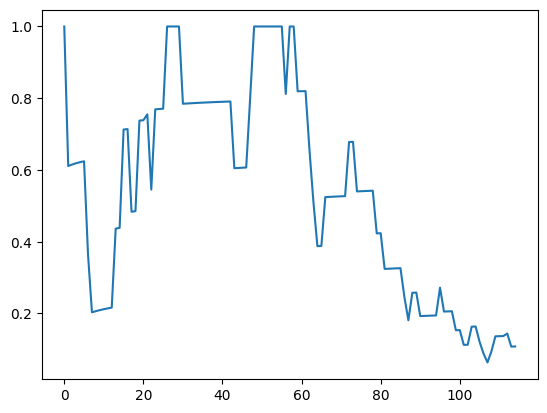

In [88]:
np.random.seed(33)

sample_size = 125

a = np.random.binomial(1, baseline, size=5000)
b = np.random.binomial(1, baseline, size=5000)
p_values = []

for i in range(10, sample_size):
  _, p_val = ztest([a[:i].sum(), b[:i].sum()], [len(a[:i]), len(b[:i])], alternative='two-sided')
  p_values.append(p_val)

pd.Series(p_values).plot();

Медленно увеличивайте sample_size (200, 300, 500, 1000). На каком значении размера выборки вы решите остановить АБ-тест и признать стат значимость?

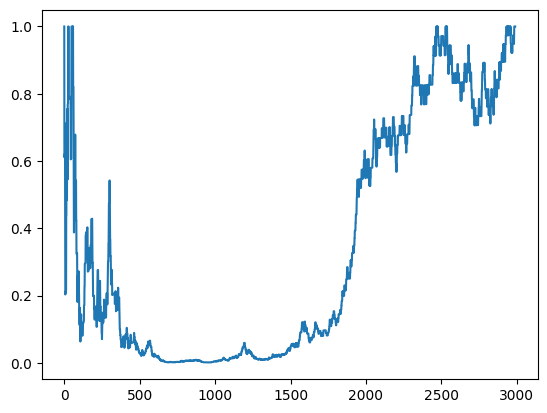

In [89]:
# code #5
np.random.seed(33)

sample_size = 3000

a = np.random.binomial(1, baseline, size=5000)
b = np.random.binomial(1, baseline, size=5000)
p_values = []

for i in range(10, sample_size):
  _, p_val = ztest([a[:i].sum(), b[:i].sum()], [len(a[:i]), len(b[:i])], alternative='two-sided')
  p_values.append(p_val)

pd.Series(p_values).plot();

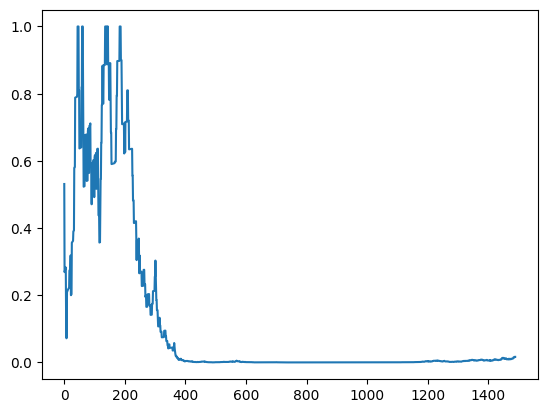

In [90]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest as ztest
from scipy.stats import norm
from tqdm.notebook import tqdm
import scipy.stats as stats
import matplotlib.pyplot as plt

baseline = 0.2
mde = 0.05
sample_size = 1500

np.random.seed(33)

a = np.random.binomial(1, baseline, size=sample_size)
b = np.random.binomial(1, baseline, size=sample_size)
p_values = []

for i in range(10, sample_size):
  _, p_val = ztest([a[:i].sum(), b[:i].sum()], [len(a[:i]), len(b[:i])], alternative='two-sided')
  p_values.append(p_val)

pd.Series(p_values).plot();

### Нарисуйте 20 линий для разных random.seed на одном графике при sample_size = 1000

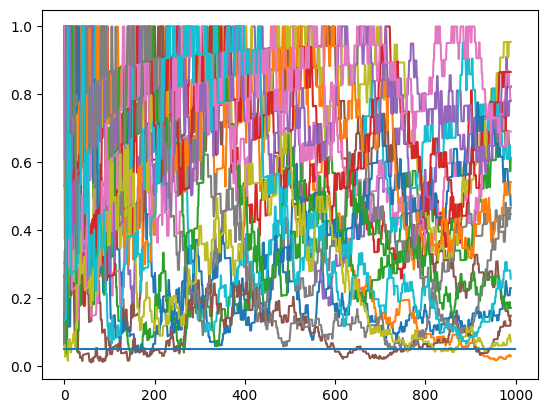

In [91]:
baseline = 0.2
mde = 0.05
sample_size = 1000
for seed in range(20):
  np.random.seed(seed)

  a = np.random.binomial(1, baseline, size=sample_size)
  b = np.random.binomial(1, baseline, size=sample_size)
  p_values = []

  for i in range(10, sample_size):
    _, p_val = ztest([a[:i].sum(), b[:i].sum()], [len(a[:i]), len(b[:i])], alternative='two-sided')
    p_values.append(p_val)

  pd.Series(p_values).plot()

pd.Series([mde]*sample_size).plot();

# U-тест Манна-Уитни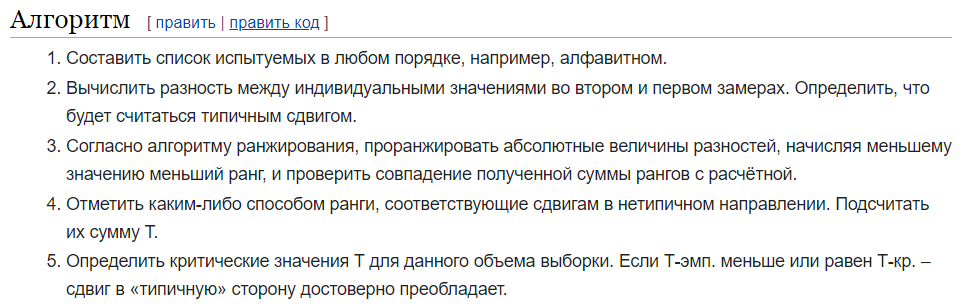

[Wiki](https://ru.wikipedia.org/wiki/U-%D0%BA%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B9_%D0%9C%D0%B0%D0%BD%D0%BD%D0%B0_%E2%80%94_%D0%A3%D0%B8%D1%82%D0%BD%D0%B8)
[YouTube](https://www.youtube.com/watch?v=IN3bB8Ea_O8)
[GitHub](https://github.com/scipy/scipy/blob/v1.11.4/scipy/stats/_mannwhitneyu.py#L250)

In [92]:
a = [1,4,6,7,9,13,15,16,20,22]
b = [3,5,8,10,11,17,19,25,28,30]

In [93]:
_ = '-'
_a = [1,_,4,_,6,7,_,9,_ ,_ ,13,15,16,_ ,_ ,20,22,_ ,_ ,_ ]
_b = [_,3,_,5,_,_,8,_,10,11,_ ,_ ,_ ,17,19,_ ,_ ,25,28,30]
_rank = list(range(1,21))
df = pd.DataFrame({'a':_a, 'b':_b, 'rank':_rank}); df

,a,b,rank
0,1,-,1
1,-,3,2
2,4,-,3
3,-,5,4
4,6,-,5
5,7,-,6
6,-,8,7
7,9,-,8
8,-,10,9
9,-,11,10


In [ ]:
l = sorted(a+b);l

[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15, 16, 17, 19, 20, 22, 25, 28, 30]

In [98]:
# code #7
data = df.to_numpy()
R1 = 0
R2 = 0
for line in data:
    if line[0] == "-":
        R2+=line[2]
    else:
        R1+=line[2]

In [99]:
R1, R2

(92, 118)

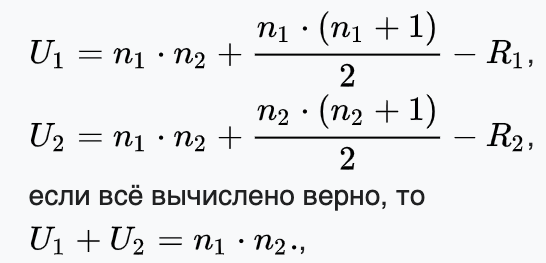

In [100]:
n1 = n2 = len(a)
U1 = n1*n2+((n1*(n1+1))/2)-R1
U2 = n1*n2+((n2*(n2+1))/2)-R2
U1, U2, U1+U2==n1*n2

(63.0, 37.0, True)

Определить значение U-статистики Манна-Уитни по формуле
$${U=\min\{U_{1},U_{2}\}.}$$

In [ ]:
U = min(U1, U2); U

37

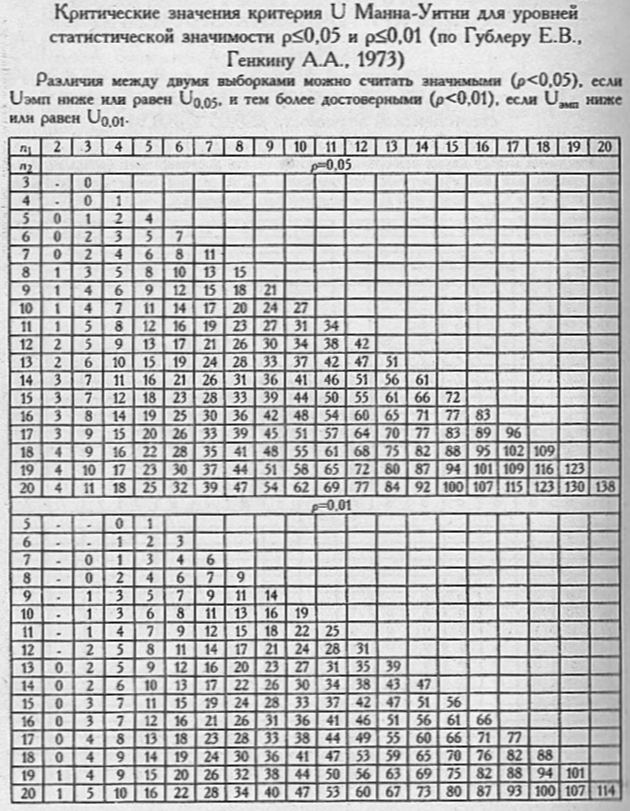

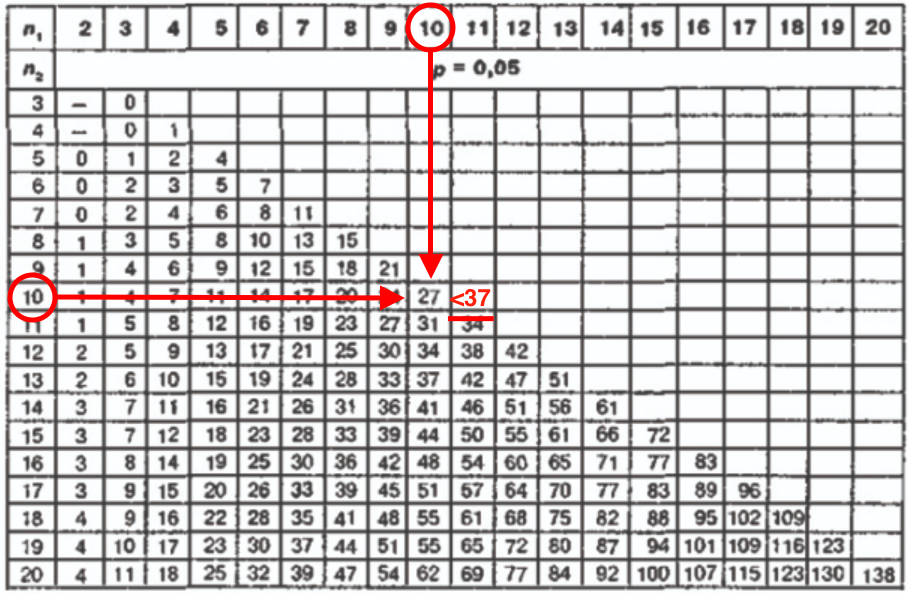

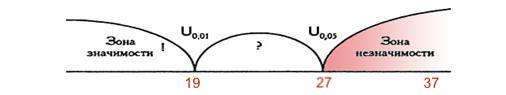

In [ ]:
U1, U2 = 63, 37 # У Вас это должно быть рассчитано выше

nx, ny = 10, 10

U = min(U1, U2)
N = nx + ny
z = (U - nx*ny/2 + 0.5) / np.sqrt(nx*ny * (N + 1)/ 12)
p = 2 * norm.cdf(z)  # use CDF to get p-value from smaller statistic
print(p)

0.3447042220069576


In [ ]:
stats.mannwhitneyu(a, b, alternative='two-sided').pvalue

0.3447042220069576

# Критерий Вилкоксона

[Wiki](https://ru.wikipedia.org/wiki/%D0%9A%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B9_%D0%A3%D0%B8%D0%BB%D0%BA%D0%BE%D0%BA%D1%81%D0%BE%D0%BD%D0%B0)
[YouTube](https://www.youtube.com/watch?v=Bh0hE7DpGD0)
[GitHub](https://github.com/scipy/scipy/blob/v1.11.4/scipy/stats/_morestats.py#L3837)

In [112]:
import collections
diff = np.array(b)-np.array(a)
abs_diff = np.abs(diff)
#calc ranks
unique, counts = np.unique(abs_diff, return_counts=True)
rank = dict(zip(unique, counts))
curr_rank = 1
print(rank)
for k in rank.keys():
    rank[k] = (rank[k]*curr_rank+(rank[k]-1))/rank[k]
    curr_rank = np.floor(rank[k]+1)
    print(curr_rank)
print(rank)
rank = [3,1,3,4,3,5.5,5.5,9,7.5,7.5]# значения 2,2,2 -> ранги 2,3,4 -> (2+3+4)/3 = 3 средний ранг
df = pd.DataFrame({'Измерение #1':a, 'Измерение #2':b, 'Разность':diff, 'По модулю':abs_diff, 'Ранг':rank}); df

{1: 1, 2: 3, 3: 1, 4: 2, 8: 2, 9: 1}
2.0
3.0
4.0
5.0
6.0
7.0
{1: 1.0, 2: 2.6666666666666665, 3: 3.0, 4: 4.5, 8: 5.5, 9: 6.0}


,Измерение #1,Измерение #2,Разность,По модулю,Ранг
0,1,3,2,2,3.0
1,4,5,1,1,1.0
2,6,8,2,2,3.0
3,7,10,3,3,4.0
4,9,11,2,2,3.0
5,13,17,4,4,5.5
6,15,19,4,4,5.5
7,16,25,9,9,9.0
8,20,28,8,8,7.5
9,22,30,8,8,7.5


В данном случае у нас есть парные измерения, и мы проверяем, есть ли статистически значимый сдвиг между ними.

**Присваиваем ранги абсолютным разностям**:
   
   Если есть одинаковые значения (например, несколько разностей равны 2), присваиваем им средний ранг. Ранги для данных:
   $$\text{rank} = [3, 1, 3, 4, 3, 5.5, 5.5, 9, 7.5, 7.5]$$
   Объяснение:
   - Значение 1 имеет ранг 1.
   - Значения 2 повторяются три раза, их ранги 2, 3, 4. Средний ранг: $ (2 + 3 + 4) / 3 = 3 $.
   - Значение 3 имеет ранг 4.
   - Значения 4 повторяются два раза, их ранги 5 и 6. Средний ранг: $ (5 + 6) / 2 = 5.5 $.
   - Значения 8 повторяются два раза, их ранги 7 и 8. Средний ранг: $ (7 + 8) / 2 = 7.5 $.
   - Значение 9 имеет ранг 9.

**Вычисляем сумму рангов для положительных и отрицательных разностей**:
   - Все разности положительные $( b > a )$, поэтому:$$ W_+ = 3 + 1 + 3 + 4 + 3 + 5.5 + 5.5 + 9 + 7.5 + 7.5 = 49 $$
   - Отрицательных разностей нет, поэтому $$ W_- = 0 $$

**Определяем статистику критерия Вилкоксона**:
   $$
   W = \min(W_+, W_-) = 0
   $$

**Проверяем статистическую значимость**:
   Сравниваем значение $ W $ с критическим значением из таблицы распределения Вилкоксона для $ n = 10 $ (количество ненулевых разностей) на уровне значимости $ \alpha = 0.05 $. Критическое значение для $ n = 10 $ и $ \alpha = 0.05 $ равно 8.

   Поскольку $ W = 0 < 8 $, нулевая гипотеза $ H_0 $ отвергается.


### Гипотезы:
- **Нулевая гипотеза $ H_0 $**: Медиана разностей между парными измерениями равна нулю (нет статистически значимого сдвига).
- **Альтернативная гипотеза $ H_1 $**: Медиана разностей между парными измерениями не равна нулю (есть статистически значимый сдвиг).


### Вывод:
На уровне значимости $ \alpha = 0.05 $ нулевая гипотеза отвергается. Это означает, что существует статистически значимый сдвиг между выборками $ a $ и $ b $. В данном случае все разности положительные $( b > a )$, что указывает на систематическое увеличение значений в выборке $ b $ по сравнению с выборкой $ a $.


In [ ]:
dif = [b[i]-a[i] for i in range(len(a))]
stats.wilcoxon(dif, alternative='two-sided', mode="approx").pvalue

0.004892240901835026

In [ ]:
T = 0
count = len(dif)
#{1: [2], 3: [1, 3, 5], 4: [4], 5.5: [6, 7], 7.5: [9, 10], 9: [8]}
repnum = np.array([3, 2, 2])
mn = count * (count + 1.) * 0.25
se = count * (count + 1.) * (2. * count + 1.)
# Correction for repeated elements.
se -= 0.5 * (repnum * (repnum * repnum - 1)).sum()
se = np.sqrt(se / 24)
d = 0#0.5 * np.sign(T - mn)
z = (T - mn - d)/ se
prob = 2. * norm.sf(abs(z))
prob = np.clip(prob, 0, 1)
prob

0.004892240901835026

In [ ]:
# Повторите с другими списками a и b

# code #8


# Bootstap

Если мы верим в то, что наши выборки ***a*** и ***b*** получены репрезентативным и честным путём, то они по сути являются мини моделями генеральных совокупностей. Если из этих выборок многократно брать случайные числа и рассчитывать медиану (или среднее значение, или процентиль), то мы сможем оценить медиану генеральной совокупности.

Из выборки ***a*** возьмите 10 случайных значений с повторениями и подсчитайте среднее. Аналогично проделайте с выборкой ***b***. Найдите разность средних. Повторите всю процедуру 1000 раз и нарисуйте гистограмму разностей средних. Рекомендуется использовать модуль numpy.

In [ ]:
def get_bootstrap(
    data_column_1, # числовые значения первой выборки
    data_column_2, # числовые значения второй выборки
    boot_it = 1000, # количество бутстрэп-подвыборок
    statistic = np.mean, # интересующая нас статистика
    bootstrap_conf_level = 0.95 # уровень значимости
):
    data_column_1 = pd.Series(data_column_1)
    data_column_2 = pd.Series(data_column_2)
    boot_len = max([len(data_column_1), len(data_column_2)])
    boot_data = []
    for i in tqdm(range(boot_it)): # извлекаем подвыборки
        samples_1 = data_column_1.sample(
            boot_len,
            replace = True # параметр возвращения
        ).values

        samples_2 = data_column_2.sample(
            boot_len, # чтобы сохранить дисперсию, берем такой же размер выборки
            replace = True
        ).values

        boot_data.append(statistic(samples_1-samples_2))
    pd_boot_data = pd.DataFrame(boot_data)

    left_quant = (1 - bootstrap_conf_level)/2
    right_quant = 1 - (1 - bootstrap_conf_level) / 2
    quants = pd_boot_data.quantile([left_quant, right_quant])

    p_1 = norm.cdf(
        x = 0,
        loc = np.mean(boot_data),
        scale = np.std(boot_data)
    )
    p_2 = norm.cdf(
        x = 0,
        loc = -np.mean(boot_data),
        scale = np.std(boot_data)
    )
    p_value = min(p_1, p_2) * 2

    # Визуализация
    _, _, bars = plt.hist(pd_boot_data[0], bins = 50)
    for bar in bars:
        if abs(bar.get_x()) <= quants.iloc[0][0] or abs(bar.get_x()) >= quants.iloc[1][0]:
            bar.set_facecolor('red')
        else:
            bar.set_facecolor('grey')
            bar.set_edgecolor('black')

    plt.style.use('ggplot')
    plt.vlines(quants,ymin=0,ymax=50,linestyle='--')
    plt.xlabel('boot_data')
    plt.ylabel('frequency')
    plt.title("Histogram of boot_data")
    plt.show()

    return {"quants": quants, "p_value": p_value}

  0%|          | 0/1000 [00:00<?, ?it/s]

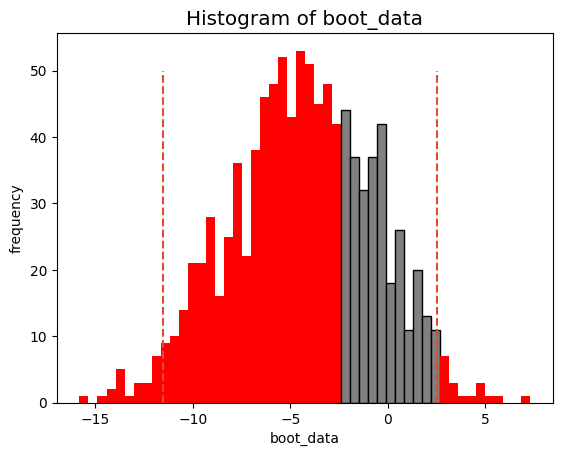

{'quants':           0
 0.025 -11.5
 0.975   2.5,
 'p_value': 0.23375271982333046}

In [ ]:
get_bootstrap(a, b)

*Доверительный интервал* (95%) для разницы средних включает ноль и это значит, что нет статистической значимости.

In [ ]:
# Напишите свою версию Bootstap

# code #9
